In [ ]:
# Copyright 2025 Bytedance Ltd. and/or its affiliates.
# SPDX-License-Identifier: Apache-2.0

In [ ]:
%load_ext autoreload
%autoreload 2

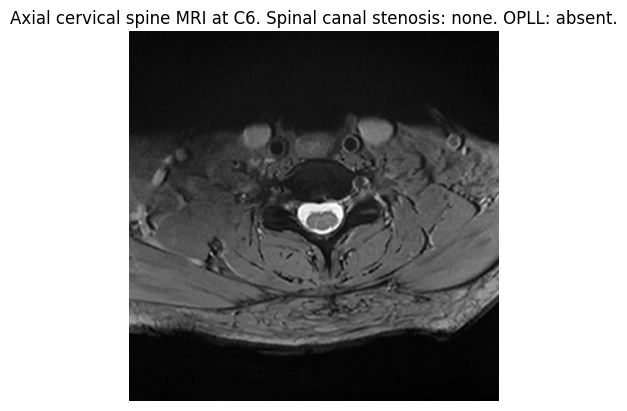

Caption: Axial cervical spine MRI at C6. Spinal canal stenosis: none. OPLL: absent.


In [1]:
import pandas as pd
from PIL import Image
import io
import json
import matplotlib.pyplot as plt

file_path = "/hdd/wangty/diffuser_workdir/bagel_example/tra_all/datapart-00000.parquet"

# 读取数据
df = pd.read_parquet(file_path)

# 取第一个样本
sample = df.iloc[0]

# ===== 1️⃣ 解析图像 =====
img_bytes = sample["image"]
img = Image.open(io.BytesIO(img_bytes))

# ===== 2️⃣ 解析 caption =====
caption_raw = sample["captions"]

# 如果是字符串（你这个就是）
caption_dict = json.loads(caption_raw)

# 一般取第一个 key
caption = list(caption_dict.values())[0]

# ===== 3️⃣ 可视化 =====
plt.imshow(img)
plt.title(caption)
plt.axis("off")
plt.show()

# 同时打印 caption
print("Caption:", caption)

In [1]:
with open("/hdd/wangty/new_task/LLaMA-Factory/task/dataset/id/id_split.txt","r") as f:
    train_id,val_id,test_id = eval(f.read())
id_list=train_id+val_id+test_id
print(len(train_id))

1561


In [2]:
import os, sys
print("python =", sys.executable)
print("LD_LIBRARY_PATH =", os.environ.get("LD_LIBRARY_PATH"))

python = /mnt/nvme_share/wangty/python/anaconda3/envs/bagel/bin/python
LD_LIBRARY_PATH = 


In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# os.environ["CUDA_HOME"] = ""  #/mnt/nvme_share/wangty/cuda-12.4
# os.environ["LD_LIBRARY_PATH"] = "" #$CUDA_HOME/lib64:$LD_LIBRARY_PATH

In [4]:
import os
from copy import deepcopy
from typing import (
    Any,
    AsyncIterable,
    Callable,
    Dict,
    Generator,
    List,
    NamedTuple,
    Optional,
    Tuple,
    Union,
)
import requests
from io import BytesIO

from PIL import Image
import torch
from accelerate import infer_auto_device_map, load_checkpoint_and_dispatch, init_empty_weights

from data.transforms import ImageTransform
from data.data_utils import pil_img2rgb, add_special_tokens
from modeling.bagel import (
    BagelConfig, Bagel, Qwen2Config, Qwen2ForCausalLM, SiglipVisionConfig, SiglipVisionModel
)
from modeling.qwen2 import Qwen2Tokenizer
from modeling.bagel.qwen2_navit import NaiveCache
from modeling.autoencoder import load_ae
from safetensors.torch import load_file

/mnt/nvme_share/wangty/python/anaconda3/envs/bagel/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Initialization

In [5]:
model_path = "/hdd/wangty/model/BAGEL-7B-MoT"  # Download from https://huggingface.co/ByteDance-Seed/BAGEL-7B-MoT

# LLM config preparing
llm_config = Qwen2Config.from_json_file(os.path.join(model_path, "llm_config.json"))
llm_config.qk_norm = True
llm_config.tie_word_embeddings = False
llm_config.layer_module = "Qwen2MoTDecoderLayer"

# ViT config preparing
vit_config = SiglipVisionConfig.from_json_file(os.path.join(model_path, "vit_config.json"))
vit_config.rope = False
vit_config.num_hidden_layers = vit_config.num_hidden_layers - 1

# VAE loading
vae_model, vae_config = load_ae(local_path=os.path.join(model_path, "ae.safetensors"))

# Bagel config preparing
config = BagelConfig(
    visual_gen=True,
    visual_und=True,  #注意这里
    llm_config=llm_config, 
    vit_config=vit_config,
    vae_config=vae_config,
    vit_max_num_patch_per_side=70,
    connector_act='gelu_pytorch_tanh',
    latent_patch_size=2,
    max_latent_size=64,
)

with init_empty_weights():
    language_model = Qwen2ForCausalLM(llm_config)
    vit_model      = SiglipVisionModel(vit_config)
    model          = Bagel(language_model, vit_model, config)
    model.vit_model.vision_model.embeddings.convert_conv2d_to_linear(vit_config, meta=True)

# Tokenizer Preparing
tokenizer = Qwen2Tokenizer.from_pretrained(model_path)
tokenizer, new_token_ids, _ = add_special_tokens(tokenizer)

# Image Transform Preparing
vae_transform = ImageTransform(1024, 512, 16)
vit_transform = ImageTransform(980, 224, 14)

## Model Loading and Multi GPU Infernece Preparing

In [ ]:
import os
import torch
from accelerate import infer_auto_device_map, load_checkpoint_and_dispatch
try:
    from safetensors import safe_open
    from safetensors.torch import save_file
except ImportError:
    raise ImportError("safetensors library not found. Install with: pip install safetensors")

def load_safetensors_dict(file_path):
    tensors = {}
    with safe_open(file_path, framework="pt") as f:
        for key in f.keys():
            tensors[key] = f.get_tensor(key)
    return tensors

def merge_safetensors(source_file, target_file, output_file):
    print(f"正在读取官方底模 (Source): {source_file}")
    source_tensors = load_safetensors_dict(source_file)
    
    print(f"正在读取微调权重 (Target): {target_file}")
    target_tensors = load_safetensors_dict(target_file)
    
    source_keys = set(source_tensors.keys())
    target_keys = set(target_tensors.keys())
    missing_keys = source_keys - target_keys
    
    print(f"发现微调权重缺失 {len(missing_keys)} 个参数 (通常是没有微调的 ViT 等部分)")
    
    if len(missing_keys) == 0:
        print("未发现缺失参数，无需合并。")
        return True
        
    merged_tensors = target_tensors.copy()
    print("正在将底模的缺失参数复制到微调权重中...")
    for key in missing_keys:
        merged_tensors[key] = source_tensors[key]
        
    print(f"正在保存完整的合并权重至: {output_file}")
    save_file(merged_tensors, output_file)
    print("合并完成！\n")
    return True

base_model_path = "/hdd/wangty/model/BAGEL-7B-MoT"
base_ema_file = os.path.join(base_model_path, "ema.safetensors")

finetuned_checkpoint_path = '/hdd/wangty/diffuser_workdir/bagel/workdir/test_5000'
finetuned_ema_file = os.path.join(finetuned_checkpoint_path, "ema.safetensors")

merged_ema_file = os.path.join(finetuned_checkpoint_path, "merged_ema.safetensors")

if not os.path.exists(merged_ema_file):
    print("未检测到合并后的完整权重，准备开始合并...")
    merge_safetensors(base_ema_file, finetuned_ema_file, merged_ema_file)
else:
    print(f"检测到已存在的完整权重文件: {merged_ema_file}，将直接加载。")


max_mem_per_gpu = "60GiB"  

device_map = infer_auto_device_map(
    model,
    max_memory={i: max_mem_per_gpu for i in range(torch.cuda.device_count())},
    no_split_module_classes=["Bagel", "Qwen2MoTDecoderLayer"],
)
print("Device Map:", device_map)

same_device_modules = [
    'language_model.model.embed_tokens',
    'time_embedder',
    'latent_pos_embed',
    'vae2llm',
    'llm2vae',
    'connector',
    'vit_pos_embed'
]

if torch.cuda.device_count() == 1:
    first_device = device_map.get(same_device_modules[0], "cuda:0")
    for k in same_device_modules:
        if k in device_map:
            device_map[k] = first_device
        else:
            device_map[k] = "cuda:0"
else:
    first_device = device_map.get(same_device_modules[0])
    for k in same_device_modules:
        if k in device_map:
            device_map[k] = first_device

# 加载合并后的完整权重 (merged_ema.safetensors)
model = load_checkpoint_and_dispatch(
    model,
    checkpoint=merged_ema_file,  # <-- 这里改为加载刚刚合并好的完整文件
    device_map=device_map,
    offload_buffers=False,
    dtype=torch.bfloat16,
    force_hooks=True,
    #offload_folder="/tmp/offload"W
)

model = model.eval()
print('Model loaded successfully with complete parameters!')

未检测到合并后的完整权重，准备开始合并...
正在读取官方底模 (Source): /hdd/wangty/model/BAGEL-7B-MoT/ema.safetensors
正在读取微调权重 (Target): /hdd/wangty/diffuser_workdir/bagel/workdir/test_5000/ema.safetensors
发现微调权重缺失 426 个参数 (通常是没有微调的 ViT 等部分)
正在将底模的缺失参数复制到微调权重中...
正在保存完整的合并权重至: /hdd/wangty/diffuser_workdir/bagel/workdir/test_5000/merged_ema.safetensors
合并完成！

Device Map: OrderedDict([('', 0)])


The safetensors archive passed at /hdd/wangty/diffuser_workdir/bagel/workdir/test_5000/merged_ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.
Some weights of the model checkpoint at /hdd/wangty/diffuser_workdir/bagel/workdir/test_5000/merged_ema.safetensors were not used when initializing Bagel: {'vit_model.vision_model.encoder.layers.4.layer_norm2.bias', 'vit_model.vision_model.encoder.layers.8.layer_norm1.bias', 'vit_model.vision_model.encoder.layers.0.mlp.fc2.bias', 'vit_model.vision_model.encoder.layers.17.layer_norm1.bias', 'vit_model.vision_model.encoder.layers.13.mlp.fc1.weight', 'vit_model.vision_model.encoder.layers.5.self_attn.q_proj.bias', 'vit_model.vision_model.encoder.layers.13.layer_norm1.weight', 'vit_model.vision_model.encoder.layers.14.mlp.fc1.weight', 'vit_model.vision_model.encoder.layers.0.self_attn.k_proj.bias', 'vit_model.vision_model.encoder.layers.21.self_attn.q_proj.bias', 

Model loaded successfully with complete parameters!


In [6]:
max_mem_per_gpu = "40GiB"  # Modify it according to your GPU setting. On an A100, 80 GiB is sufficient to load on a single GPU.
checkpoint_path = "/hdd/wangty/diffuser_workdir/bagel/workdir/zjxxz/4500"
#       "/hdd/wangty/model/BAGEL-7B-MoT"

device_map = {"": "cuda:0"}
print(device_map)

# same_device_modules = [
#     'language_model.model.embed_tokens',
#     'time_embedder',
#     'latent_pos_embed',
#     'vae2llm',
#     'llm2vae',
#     'connector',
#     'vit_pos_embed'
# ]

# if torch.cuda.device_count() == 1:
#     first_device = device_map.get(same_device_modules[0], "cuda:0")
#     for k in same_device_modules:
#         if k in device_map:
#             device_map[k] = first_device
#         else:
#             device_map[k] = "cuda:0"
# else:
#     first_device = device_map.get(same_device_modules[0])
#     for k in same_device_modules:
#         if k in device_map:
#             device_map[k] = first_device

# Thanks @onion-liu: https://github.com/ByteDance-Seed/Bagel/pull/8
model = load_checkpoint_and_dispatch(
    model,
    checkpoint=os.path.join(checkpoint_path, "model.safetensors"),
    device_map=device_map,
    offload_buffers=False,
    dtype=torch.bfloat16,
    force_hooks=True,
    # offload_folder="/tmp/offload"
)

model = model.eval()
print('Model loaded')

The safetensors archive passed at /hdd/wangty/diffuser_workdir/bagel/workdir/zjxxz/4500/model.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.


{'': 'cuda:0'}
Model loaded


## Inferencer Preparing 

In [7]:
from inferencer import InterleaveInferencer

inferencer = InterleaveInferencer(
    model=model, 
    vae_model=vae_model, 
    tokenizer=tokenizer, 
    vae_transform=vae_transform, 
    vit_transform=vit_transform, 
    new_token_ids=new_token_ids
)

In [8]:
import random
import numpy as np

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
import json
with open('/hdd/wangty/new_task/LLaMA-Factory/task/dataset/process_data.json',"r") as f:
    data=json.load(f)
with open("/hdd/wangty/new_task/LLaMA-Factory/task/dataset/id/id_split.txt","r") as f:
    train_id,val_id,test_id = eval(f.read())
id_list=train_id+val_id+test_id

**About Inference Hyperparameters:**
- **`cfg_text_scale`:** Controls how strongly the model follows the text prompt. `1.0` disables text guidance. Typical range: `4.0–8.0`.
- **`cfg_image_scale`:** Controls how much the model preserves input image details. `1.0` disables image guidance. Typical range: `1.0–2.0`.
- **`cfg_interval`:** Fraction of denoising steps where CFG is applied. Later steps can skip CFG to reduce computation. Typical: `[0.4, 1.0]`.
- **`timestep_shift`:** Shifts the distribution of denoising steps. Higher values allocate more steps at the start (affects layout); lower values allocate more at the end (improves details).
- **`num_timesteps`:** Total denoising steps. Typical: `50`.
- **`cfg_renorm_min`:** Minimum value for CFG-Renorm. `1.0` disables renorm. Typical: `0`.
- **`cfg_renorm_type`:** CFG-Renorm method:  
  - `global`: Normalize over all tokens and channels (default for T2I).
  - `channel`: Normalize across channels for each token.
  - `text_channel`: Like `channel`, but only applies to text condition (good for editing, may cause blur).
- **If edited images appear blurry, try `global` CFG-Renorm, decrease `cfg_renorm_min` or decrease `cfg_scale`.**


## format interleave

In [47]:
import random
pid = random.choice(test_id)
print(pid)
data[pid]['zjxxz']#[::2]

01240611219011


[1, 1, 0, 0]

In [50]:
from PIL import Image
from inferencer import InterleaveInferencer

image = Image.open(f"/mnt/nvme_share/wangty/img/sag_512/{pid}.png").convert("RGB")

level="the C5-6 disc space"
prompt = f"Assess disc space narrow at the {level} level on this sagittal cervical spine MRI. The options are: normal, narrow. For text-based thinking, enclose the process within <think> </think>. For visual thinking, enclose the content within <image_start> </image_end>. Finally conclude with the final answer wrapped in <answer></answer> tags."

output = inferencer(
    image=image,
    text=prompt,
    think=True,
    use_interleave_format_prompt=True,
    understanding_output=False,
    do_sample=False,
    text_temperature=0.3,
    max_think_token_n=256,
    cfg_text_scale=4.0,
    cfg_img_scale=2.0,
    cfg_interval=(0.4, 1.0),
    timestep_shift=3.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="global",
    max_rounds=2,
)


100%|██████████| 49/49 [00:16<00:00,  3.04it/s]



=== output[0] ===
<think>To assess disc space narrow at C5-6, I should first focus on the C5-6 disc space.</think><image_start>

=== output[1] ===


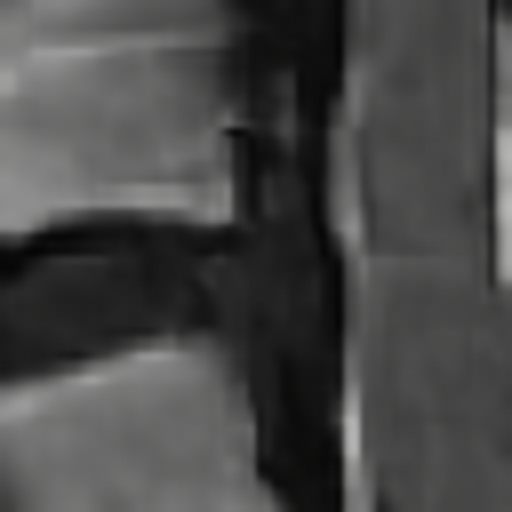


=== output[2] ===
<image_end><answer>normal</answer>


In [52]:
for i, item in enumerate(output["output_list"]):
    print(f"\n=== output[{i}] ===")
    if isinstance(item, str):
        print(item)
    else:
        display(item)


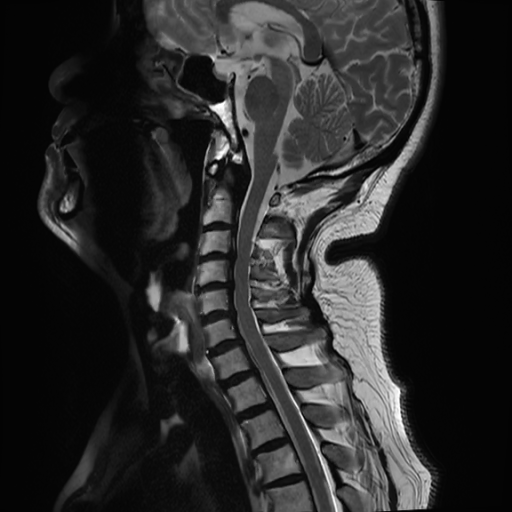

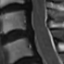

In [53]:
display(image)
img_1=Image.open(f'/mnt/nvme_share/wangty/img/sag_crop_64/{pid}/5-6.png').convert("RGB")
display(img_1)

## Image Generation

In [8]:
# inference_hyper=dict(
#     cfg_text_scale=4.0,
#     cfg_img_scale=1.0,
#     cfg_interval=[0.4, 1.0],
#     timestep_shift=1.0,
#     num_timesteps=50,
#     cfg_renorm_min=0.0,
#     cfg_renorm_type="global",
#     image_shapes=(512,512),
# )
inference_hyper = dict(
    cfg_text_scale=1.0,
    cfg_img_scale=1.0,
    cfg_interval=[0.4, 1.0],
    timestep_shift=1.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="global",
    image_shapes=(512, 512),
)

In [9]:
# from safetensors import safe_open
# import torch

# def load_safetensors_dict(file_path):
#     tensors = {}
#     with safe_open(file_path, framework="pt") as f:
#         for key in f.keys():
#             tensors[key] = f.get_tensor(key)
#     return tensors

# base = load_safetensors_dict(base_ema_file)
# ft = load_safetensors_dict(finetuned_ema_file)

# common_keys = sorted(set(base.keys()) & set(ft.keys()))
# print("common keys:", len(common_keys))

# diff_count = 0
# total_l2 = 0.0
# show = []

# for k in common_keys:
#     if base[k].dtype.is_floating_point and ft[k].dtype.is_floating_point:
#         diff = (ft[k].to(torch.bfloat16).float() - base[k].to(torch.bfloat16).float()).norm().item()
#         total_l2 += diff
#         if diff > 0:
#             diff_count += 1
#             if len(show) < 20:
#                 show.append((k, diff))

# print("different keys:", diff_count)
# print("total l2 diff:", total_l2)
# print("examples:", show)

In [ ]:
prompt = "A female cosplayer portraying an ethereal fairy or elf, wearing a flowing dress made of delicate fabrics in soft, mystical colors like emerald green and silver. She has pointed ears, a gentle, enchanting expression, and her outfit is adorned with sparkling jewels and intricate patterns. The background is a magical forest with glowing plants, mystical creatures, and a serene atmosphere."
# prompt='a cervical spine MRI sagittal T2 image'
print(prompt)
print('-' * 10)
output_dict = inferencer(text=prompt, **inference_hyper)
display(output_dict['image'])

A female cosplayer portraying an ethereal fairy or elf, wearing a flowing dress made of delicate fabrics in soft, mystical colors like emerald green and silver. She has pointed ears, a gentle, enchanting expression, and her outfit is adorned with sparkling jewels and intricate patterns. The background is a magical forest with glowing plants, mystical creatures, and a serene atmosphere.
----------


100%|██████████| 49/49 [00:09<00:00,  5.32it/s]


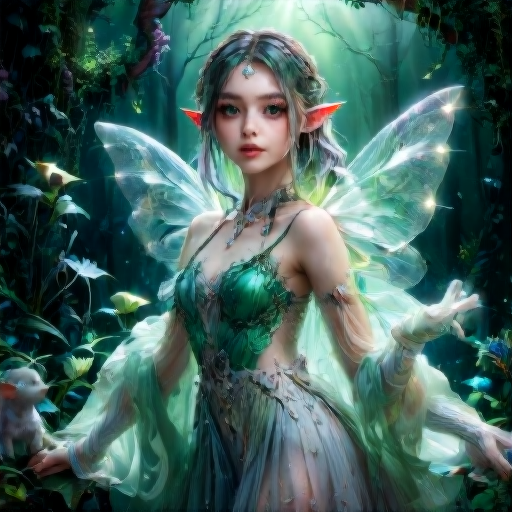

In [12]:
prompt = "A female cosplayer portraying an ethereal fairy or elf, wearing a flowing dress made of delicate fabrics in soft, mystical colors like emerald green and silver. She has pointed ears, a gentle, enchanting expression, and her outfit is adorned with sparkling jewels and intricate patterns. The background is a magical forest with glowing plants, mystical creatures, and a serene atmosphere."
# prompt='a cervical spine MRI sagittal T2 image'
print(prompt)
print('-' * 10)
output_dict = inferencer(text=prompt, **inference_hyper)
display(output_dict['image'])

In [ ]:
img = output_dict['image']
save_filename = "mri_generated_image.png"
save_path = os.path.join(os.getcwd(), save_filename)
img.save(save_path)

## Image Generation with Think

In [10]:
inference_hyper=dict(
    max_think_token_n=1000,
    do_sample=False,
    # text_temperature=0.3,
    cfg_text_scale=4.0,
    cfg_img_scale=1.0,
    cfg_interval=[0.4, 1.0],
    timestep_shift=3.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="global",
)

In [ ]:
prompt = 'a car made of small cars'

print(prompt)
print('-' * 10)
output_dict = inferencer(text=prompt, think=True, **inference_hyper)
print(output_dict['text'])
display(output_dict['image'])

## edit and gen

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open('/mnt/nvme_share/wangty/img/sag_512/02240515201024.png').convert("RGB")

prompt = "For the sagittal cervical spine MRI, determine the spinal canal stenosis grade at C3.To assess spinal canal stenosis at C3, I should first focus on the C3 vertebral body and adjacent spinal canal."

output = inferencer(
    image=image,
    text=prompt,
    image_first=True,
    do_sample=False,
    max_think_token_n=256,
    cfg_text_scale=3.0,
    cfg_img_scale=1.5,
    num_timesteps=50,
)

plt.figure(figsize=(6, 6))
plt.imshow(output["image"])
plt.axis("off")
plt.show()

print(output["text"])

In [ ]:
output = inferencer(
    image=image,
    text=prompt,
    image_first=True,
    do_sample=False,
    text_temperature=0.3,
    max_think_token_n=256,
    cfg_text_scale=3.0,
    cfg_img_scale=1.5,
    cfg_interval=(0.4, 1.0),
    timestep_shift=3.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="global",
)

## Editing

In [9]:
inference_hyper=dict(
    cfg_text_scale=4.0,
    cfg_img_scale=2.0,
    cfg_interval=[0.0, 1.0],
    timestep_shift=3.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="text_channel",
)

In [ ]:
image = Image.open('test_images/women.jpg')
prompt = 'She boards a modern subway, quietly reading a folded newspaper, wearing the same clothes.'

display(image)
print(prompt)
print('-'*10)
output_dict = inferencer(image=image, text=prompt, **inference_hyper)
display(output_dict['image'])

In [10]:
with open("/hdd/wangty/new_task/LLaMA-Factory/task/dataset/id/id_split.txt","r") as f:
    train_id,val_id,test_id = eval(f.read())
id_list=train_id+val_id+test_id
print(test_id[:10])

['02240515201024', '02240505218050', '01240514214099', '01240416213015', '02240507218029', '01240506208113', '01240604208009', '01240528210020', '01240526221011', '02240509219063']


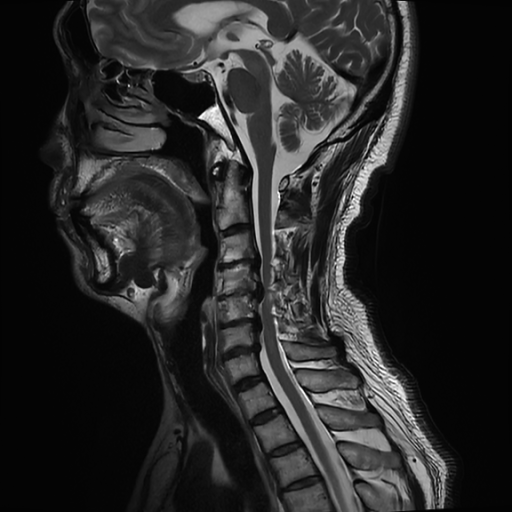

Crop the sagittal cervical spine MRI to the C3 vertebral body region
----------


100%|██████████| 49/49 [00:55<00:00,  1.13s/it]


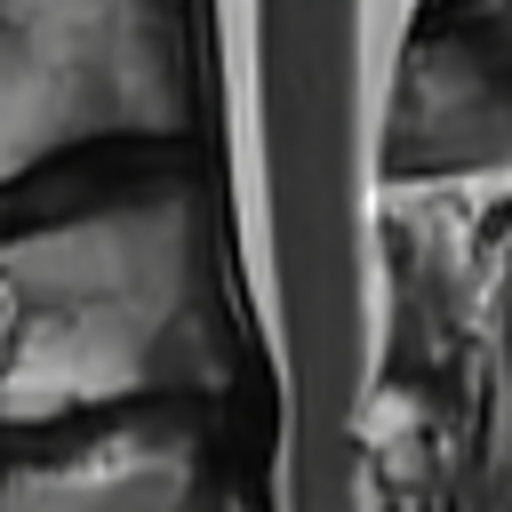

In [11]:
img_path='/mnt/nvme_share/wangty/img/sag_512/02240515201024.png'  #'test_images/aveiro1.jpg'
image = Image.open(img_path)
prompt = "Crop the sagittal cervical spine MRI to the C3 vertebral body region"

display(image)
print(prompt)
print('-'*10)
output_dict = inferencer(image=image, text=prompt, **inference_hyper)
display(output_dict['image'])

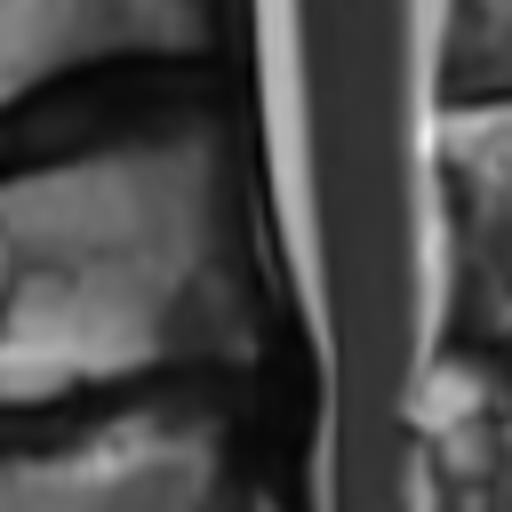

In [16]:
p='/mnt/nvme_share/wangty/img/sag_crop_64/02240515201024/3.png'
image = Image.open(p).resize((512,512))
display(image)

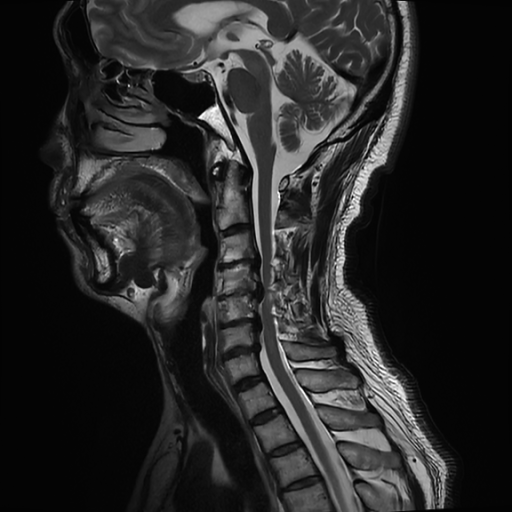

Crop the sagittal cervical spine MRI to the C3-C4 intervertebral disc region
----------


100%|██████████| 49/49 [00:55<00:00,  1.12s/it]


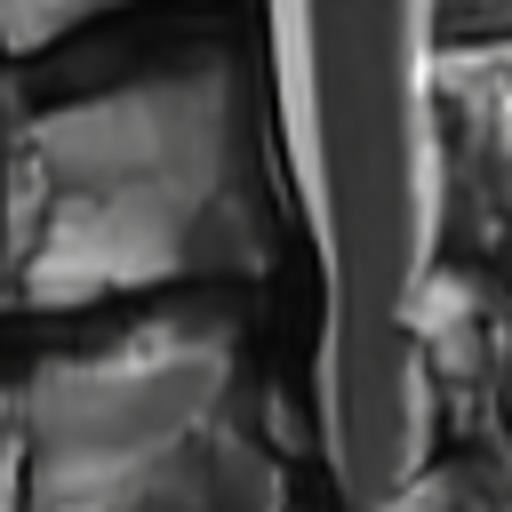

In [17]:
img_path='/mnt/nvme_share/wangty/img/sag_512/02240515201024.png'  #'test_images/aveiro1.jpg'
image = Image.open(img_path)
prompt = "Crop the sagittal cervical spine MRI to the C3-C4 intervertebral disc region"

display(image)
print(prompt)
print('-'*10)
output_dict = inferencer(image=image, text=prompt, **inference_hyper)
display(output_dict['image'])

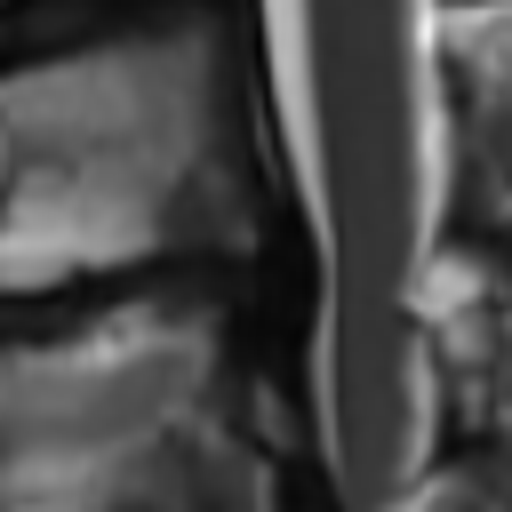

In [18]:
p='/mnt/nvme_share/wangty/img/sag_crop_64/02240515201024/3-4.png'
image = Image.open(p).resize((512,512))
display(image)

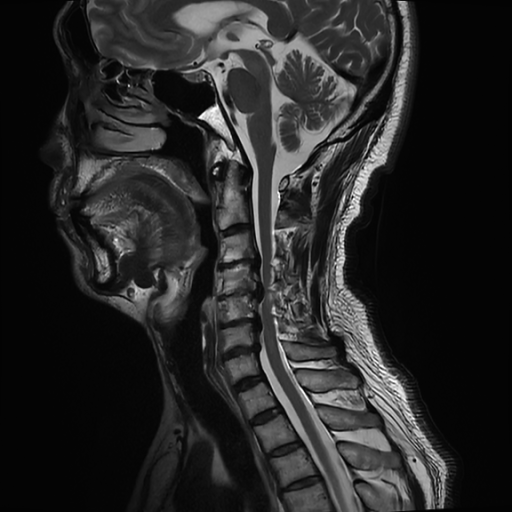

Crop the sagittal cervical spine MRI to the C7 vertebral body region
----------


100%|██████████| 49/49 [00:46<00:00,  1.06it/s]


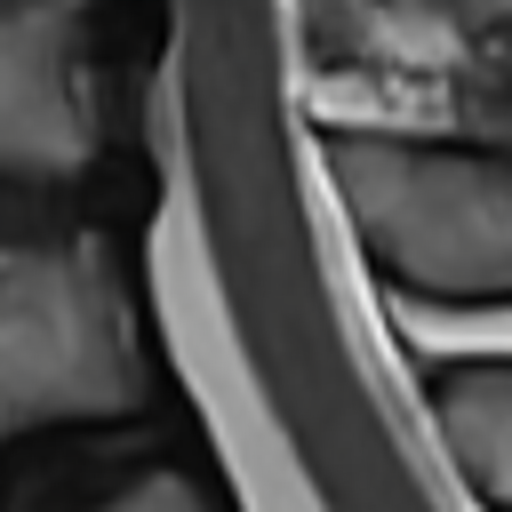

In [19]:
img_path='/mnt/nvme_share/wangty/img/sag_512/02240515201024.png'  #'test_images/aveiro1.jpg'
image = Image.open(img_path)
prompt = "Crop the sagittal cervical spine MRI to the C7 vertebral body region"

display(image)
print(prompt)
print('-'*10)
output_dict = inferencer(image=image, text=prompt, **inference_hyper)
display(output_dict['image'])

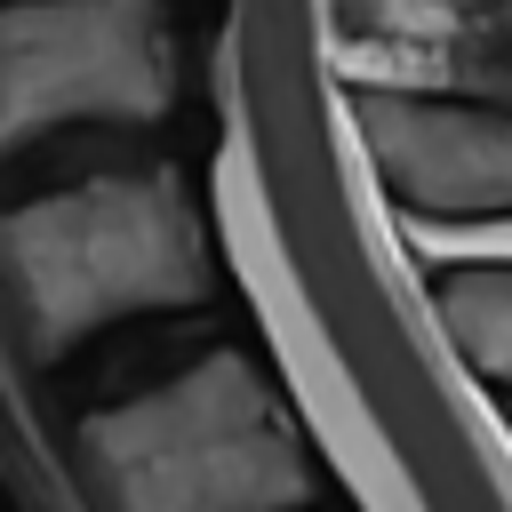

In [20]:
p='/mnt/nvme_share/wangty/img/sag_crop_64/02240515201024/7.png'
image = Image.open(p).resize((512,512))
display(image)

## Edit with Think

In [ ]:
inference_hyper=dict(
    max_think_token_n=1000,
    do_sample=False,
    # text_temperature=0.3,
    cfg_text_scale=4.0,
    cfg_img_scale=2.0,
    cfg_interval=[0.0, 1.0],
    timestep_shift=3.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="text_channel",
)

In [ ]:
image = Image.open('test_images/octupusy.jpg')
prompt = 'Could you display the sculpture that takes after this design?'

display(image)
print('-'*10)
output_dict = inferencer(image=image, text=prompt, think=True, **inference_hyper)
print(output_dict['text'])
display(output_dict['image'])

## Understanding

In [ ]:
inference_hyper=dict(
    max_think_token_n=1000,
    do_sample=False,
    # text_temperature=0.3,
)

In [ ]:
image = Image.open('test_images/meme.jpg')
prompt = "Can someone explain what’s funny about this meme??"

display(image)
print(prompt)
print('-'*10)
output_dict = inferencer(image=image, text=prompt, understanding_output=True, **inference_hyper)
print(output_dict['text'])

## TaylorSeer Support for Inference Acceleration

In [ ]:
# Enable TaylorSeer (https://arxiv.org/abs/2503.06923) by setting enable_taylorseer=True in inference_hyper
# This feature is supported for tasks that involve image output, including image generation, image generation with think, editing, and edit with think.

# Below is an example of image generation with TaylorSeer enabled.
inference_hyper=dict(
    cfg_text_scale=4.0,
    cfg_img_scale=1.0,
    cfg_interval=[0.4, 1.0],
    timestep_shift=3.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="global",
    enable_taylorseer=True,  # Enable TaylorSeer
)

In [ ]:
prompt = "A female cosplayer portraying an ethereal fairy or elf, wearing a flowing dress made of delicate fabrics in soft, mystical colors like emerald green and silver. She has pointed ears, a gentle, enchanting expression, and her outfit is adorned with sparkling jewels and intricate patterns. The background is a magical forest with glowing plants, mystical creatures, and a serene atmosphere."

print(prompt)
print('-' * 10)
output_dict = inferencer(text=prompt, **inference_hyper)
display(output_dict['image'])